# Introduction to _NatureDataCube_

This tutorial was made for the Veluwe Research Community Meeting on June 30th, 2026.

## What is _NatureDataCube_?

_NatureDataCube_ is a tool to facilitate access to data for nature areas in the Netherlands. It is under active development under the context of LTER-LIFE.

### Load all packages needed

In [2]:
# Load packages
library(NatureDataCubeR)
library(rstac)
library(sf)
library(terra)
library(dplyr)

### Define _NatureDataCube_ authentication token

Tokens can be requested freely here: <https://ndc.wur.nl/register>.

In [2]:
ndc_token <- Sys.getenv("NDC_TOKEN")

## Boundaries

We will start by loading the boundaries for the Netherlands and the Veluwe, as geospatial polygons:

In [3]:
# Netherlands
path_nl <- system.file("extdata/nl.gpkg", package = "NatureDataCubeR")
nl <- ndc_roi(path_nl)

# Veluwe
path_veluwe <- system.file("extdata/veluwe.gpkg", package = "NatureDataCubeR")
veluwe <- ndc_roi(path_veluwe)

These can then be visualised in a map:

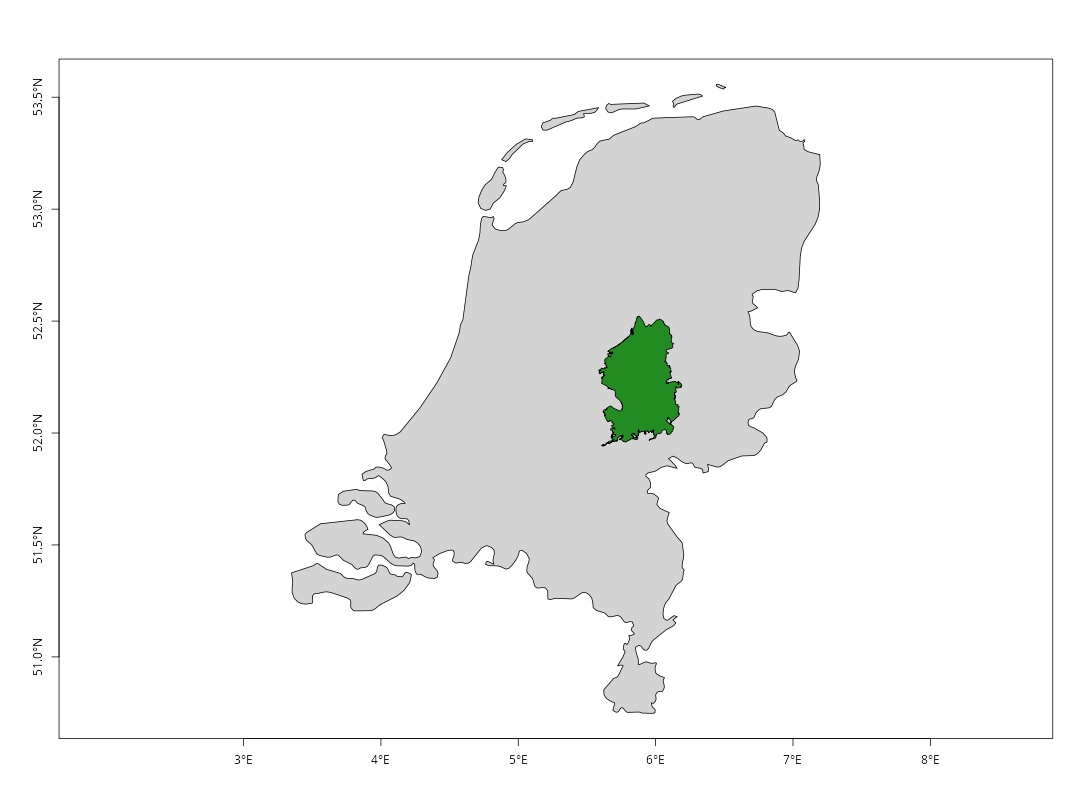

In [4]:
# Plot boundaries for the Netherlands
nl |>
  st_geometry() |>
  plot(col = "lightgray", axes = TRUE)

# Add boundaries for the Veluwe
veluwe |>
  st_geometry() |>
  plot(col = "forestgreen", add = TRUE)

The study area(s) in which we are interested can be obrained from _NatureDataCube_.

Let's first list which datasets are (currently) available from the _NatureDataCube_ STAC endpoint:

In [5]:
ndc_datasets()

[1] "ndvi-lter"              "ndvi-snl"               "ndc-geoserver-rasters" 
[4] "lter"                   "snl"                    "groenmonitor-geoserver"

Our region(s) of interest are stored in the "lter" dataset. So, we can retrieve the polygons within this dataset that overlap with the Veluwe, as an "sf" object:

In [6]:
lter <- ndc_get(collection = "lter",
                roi = veluwe,
                mode = "sf")
print(lter)

Simple feature collection with 28 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
# A tibble: 28 × 5
   datetime             name            ndc_id  `proj:epsg`                                  geometry
   <chr>                <chr>           <chr>         <int>                        <MULTIPOLYGON [°]>
 1 2026-05-04T23:29:36Z Lantaarnpaal 23 1264498       28992 (((5.897287 52.37654, 5.897207 52.37659,…
 2 2026-05-04T23:29:36Z Lantaarnpaal 22 1264497       28992 (((5.894901 52.37464, 5.894821 52.37469,…
 3 2026-05-04T23:29:36Z Lantaarnpaal 21 1264496       28992 (((5.891346 52.37197, 5.891269 52.37202,…
 4 2026-05-04T23:29:36Z Lantaarnpaal 20 1264495       28992 (((5.888648 52.36964, 5.888567 52.36969,…
 5 2026-05-04T23:29:36Z Lantaarnpaal 19 1264494       28992 (((5.932585 52.09907, 5.932537 52.09906,…
 6 2026-05-04T23:29:36Z Lantaarnpaal 18 1264493       28992 (((5.932

Visualise the LTER sites in the context of the Veluwe:

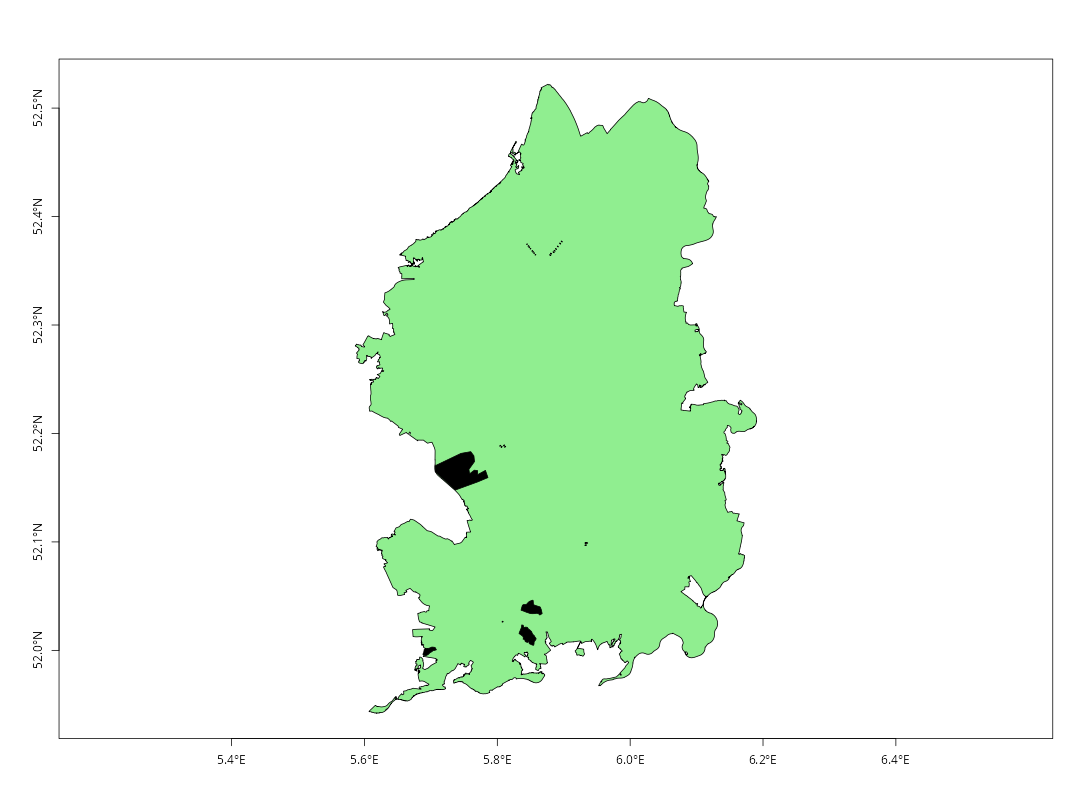

In [7]:
# Plot boundaries for the Veluwe
veluwe |>
  st_geometry() |>
  plot(col = "lightgreen", axes = TRUE)

# Add boundaries for the retrieved LTER sites
lter |>
  st_geometry() |>
  plot(col = "black", add = TRUE)

Now, we can subset the LTER sites, as our regions-of-interest are limited to the polygons that correspond to the nestboxes study areas:

In [8]:
nest_roi <- lter |>
  filter(substr(name, 1, 4) == "Nest")
print(nest_roi)

Simple feature collection with 3 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.867511 ymax: 52.04628
Geodetic CRS:  WGS 84
# A tibble: 3 × 5
  datetime             name              ndc_id  `proj:epsg`                                 geometry
* <chr>                <chr>             <chr>         <int>                       <MULTIPOLYGON [°]>
1 2026-05-04T23:29:36Z Nestkast Veluwe   1264472       28992 (((5.837216 52.04044, 5.837859 52.04163…
2 2026-05-04T23:29:36Z Nestkast Boslust  1264470       28992 (((5.836293 52.02099, 5.836806 52.02346…
3 2026-05-04T23:29:36Z Nestkast Bennekom 1264469       28992 (((5.689241 51.9972, 5.689912 52.00078,…


Let's now visualise these areas in the map:

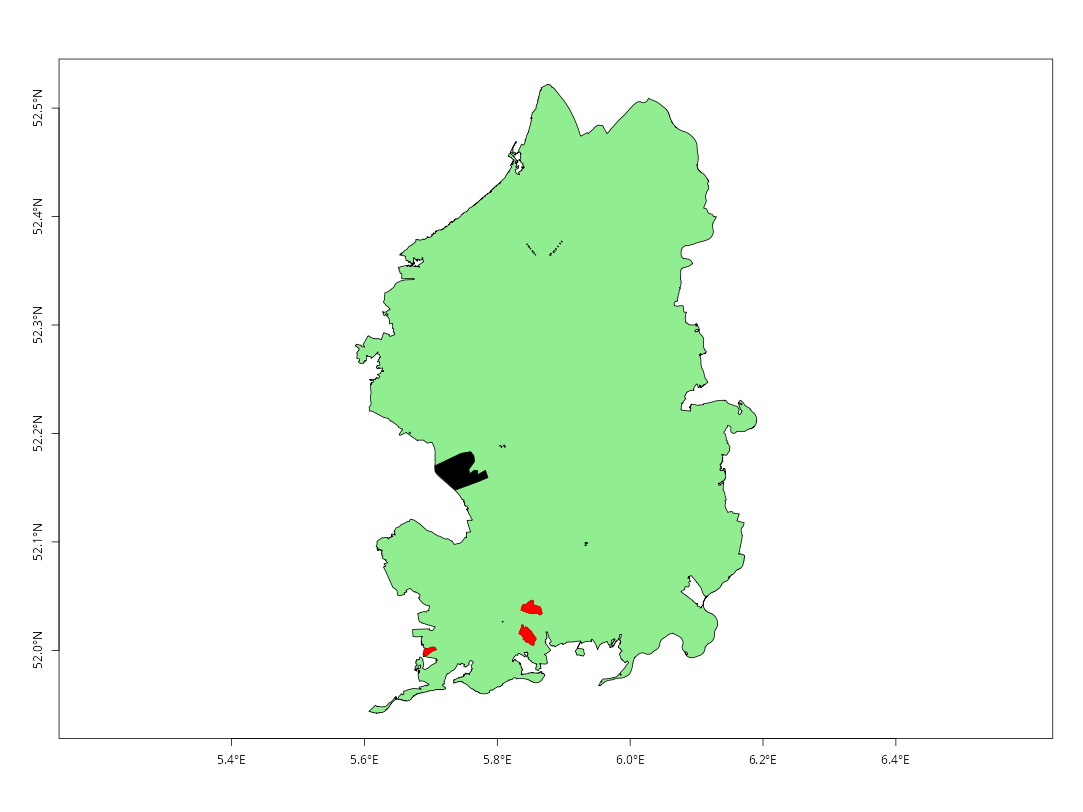

In [9]:
# Plot boundaries for the Veluwe
veluwe |>
  st_geometry() |>
  plot(col = "lightgreen", axes = TRUE)

# Add boundaries for (all of) the retrieved LTER sites
lter |>
  st_geometry() |>
  plot(col = "black", add = TRUE)

# Add boundaries for the subsetted LTER sites
nest_roi |>
  st_geometry() |>
  plot(col = "red", border = "red", add = TRUE)

We can store the IDs of the polygons in which we are interested in a "character vector" object:

In [10]:
nest_roi_ids <- unique(nest_roi$ndc_id)
print(nest_roi_ids)

[1] "1264472" "1264470" "1264469"


## Focus dataset

The nests dataset can be retrieved from this folder:

In [11]:
nestboxes_path <- "~/Downloads/first_nests_HV.csv"

Load the data and ensure it looks as expected:

In [12]:
nestboxes <- read.csv(nestboxes_path)
print(head(nestboxes, n = 15))

   year nestbox_id   lat_dd   lon_dd         species   lay_date clutch_size ld_doy
1  1955  HV.0001.0 52.04431 5.845903       great tit 1955-05-01          12    121
2  1957  HV.0001.0 52.04431 5.845903       great tit 1957-04-15           8    105
3  1961  HV.0001.0 52.04431 5.845903       great tit 1961-04-11          10    101
4  1965  HV.0001.0 52.04431 5.845903       great tit 1965-05-04          12    124
5  1967  HV.0001.0 52.04431 5.845903       great tit 1967-04-16           9    106
6  1968  HV.0001.0 52.04431 5.845903 pied flycatcher 1968-05-07           6    128
7  1969  HV.0001.0 52.04431 5.845903 pied flycatcher 1969-05-06           6    126
8  1971  HV.0001.0 52.04431 5.845903       great tit 1971-04-19          10    109
9  1972  HV.0001.0 52.04431 5.845903       great tit 1972-04-24           9    115
10 1973  HV.0001.0 52.04621 5.854121       great tit 1973-04-24          13    114
11 1974  HV.0001.0 52.04621 5.854121       great tit 1974-04-19           8    109
12 1

This dataset can be subsetted for records between 2019 and 2025 as follows:

In [13]:
nestboxes <- nestboxes |>
  filter(year >= 2019 & year <= 2025)
print(head(nestboxes, n = 15))

   year nestbox_id   lat_dd   lon_dd         species   lay_date clutch_size ld_doy
1  2019  HV.0001.0 52.04621 5.854121       great tit 2019-04-11           8    101
2  2020  HV.0001.0 52.04621 5.854121       great tit 2020-04-18          10    109
3  2021  HV.0001.0 52.04621 5.854121       great tit 2021-04-26          10    116
4  2022  HV.0001.0 52.04621 5.854121       great tit 2022-04-15           8    105
5  2023  HV.0001.0 52.04621 5.854121       great tit 2023-04-18           7    108
6  2024  HV.0001.0 52.04621 5.854121       great tit 2024-04-09          11    100
7  2025  HV.0001.0 52.04621 5.854121       great tit 2025-04-11          11    101
8  2019  HV.0002.0 52.04632 5.853758       great tit 2019-04-17           7    107
9  2020  HV.0002.0 52.04632 5.853758       great tit 2020-04-17           8    108
10 2021  HV.0002.0 52.04632 5.853758 pied flycatcher 2021-05-11           6    131
11 2022  HV.0002.0 52.04632 5.853758        blue tit 2022-04-15           9    105
12 2

Using the latitude and longitude fields within the nestbox data, the dataset can be converted into an "sf" spatial points object:

In [14]:
nestboxes <- nestboxes |>
  st_as_sf(coords = c("lon_dd", "lat_dd"), crs = 4326)
print(nestboxes)

Simple feature collection with 2423 features and 6 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 5.835793 ymin: 52.0325 xmax: 5.866197 ymax: 52.04632
Geodetic CRS:  WGS 84
First 10 features:
   year nestbox_id         species   lay_date clutch_size ld_doy                  geometry
1  2019  HV.0001.0       great tit 2019-04-11           8    101 POINT (5.854121 52.04621)
2  2020  HV.0001.0       great tit 2020-04-18          10    109 POINT (5.854121 52.04621)
3  2021  HV.0001.0       great tit 2021-04-26          10    116 POINT (5.854121 52.04621)
4  2022  HV.0001.0       great tit 2022-04-15           8    105 POINT (5.854121 52.04621)
5  2023  HV.0001.0       great tit 2023-04-18           7    108 POINT (5.854121 52.04621)
6  2024  HV.0001.0       great tit 2024-04-09          11    100 POINT (5.854121 52.04621)
7  2025  HV.0001.0       great tit 2025-04-11          11    101 POINT (5.854121 52.04621)
8  2019  HV.0002.0       great tit 2019-04-17           7   

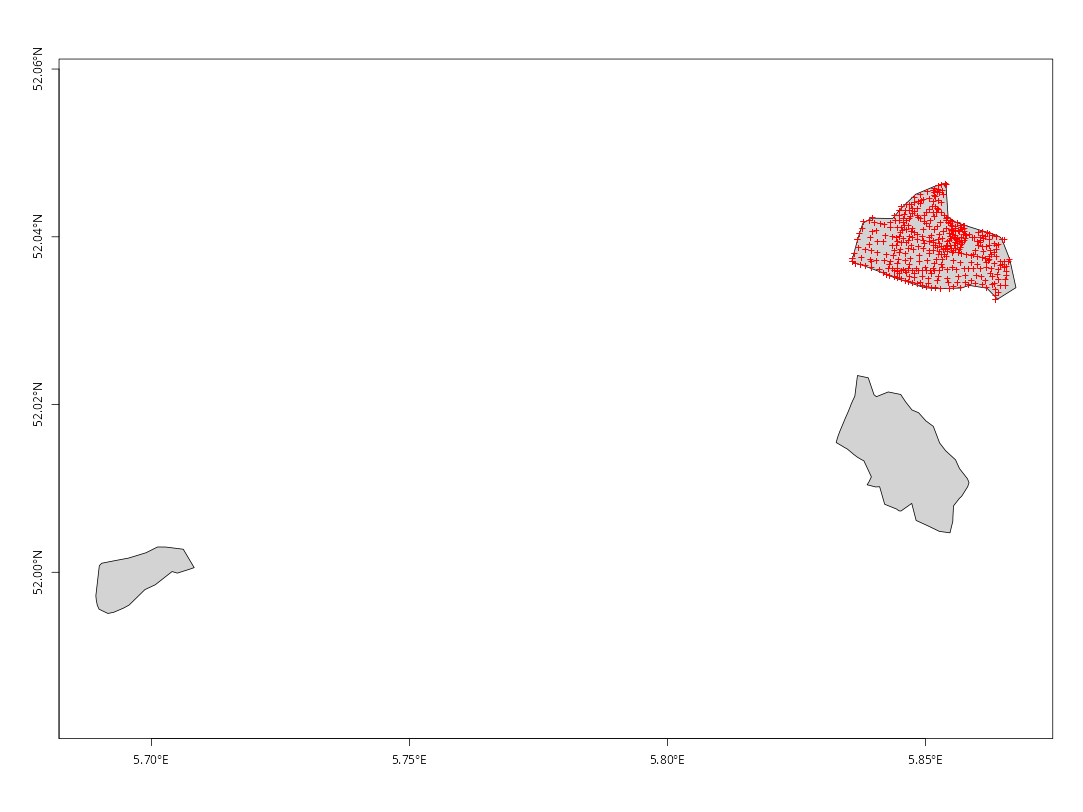

In [15]:
# Plot boundaries for the nestbox LTER sites
nest_roi |>
  st_geometry() |>
  plot(col = "lightgrey", axes = TRUE)

# Add nestbox locations
nestboxes |>
  st_geometry() |>
  plot(pch = "+", col = "red", add = TRUE)

We can extract several different aggregate statistics from the data. For example, the mean clutch size, per species and per year, can be calculated as follows:

In [21]:
nestboxes_mean_clutch_size <- nestboxes |>
  as_tibble() |>
  summarize(clutch_size = mean(clutch_size, na.rm = TRUE),
            .by = c(species, year))
print(nestboxes_mean_clutch_size)

# A tibble: 31 × 3
   species          year clutch_size
   <chr>           <int>       <dbl>
 1 great tit        2019        7.85
 2 great tit        2020        8.81
 3 great tit        2021        8.05
 4 great tit        2022        8.79
 5 great tit        2023        7.95
 6 great tit        2024        9.37
 7 great tit        2025        8.87
 8 pied flycatcher  2021        6.27
 9 blue tit         2022       10.1 
10 pied flycatcher  2020        6.74
# ℹ 21 more rows
# ℹ Use `print(n = ...)` to see more rows


After this, how many annual mean clutch size values for each species?

In [27]:
table(nestboxes_mean_clutch_size$species)


       blue tit        coal tit       great tit       marsh tit        nuthatch pied flycatcher 
              7               1               7               2               7               7 

## NDVI

First, let's define the time period in which we are interested:

In [19]:
tperiod <- ndc_trange(c("2019-01-01", "2025-12-31"))

Then, we can get the NDVI statistics for the LTER sites that overlap the Veluwe, within the chosen time period:

In [20]:
ndvi <- ndc_get(collection = "ndvi-lter",
                roi = veluwe,
                trange = tperiod,
                mode = "sf",
                limit = 10000)
print(ndvi)

Simple feature collection with 5810 features and 9 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.936116 ymax: 52.37747
Geodetic CRS:  WGS 84
# A tibble: 5,810 × 10
   datetime         ndc_id ndvi_count ndvi_mean ndvi_std observation_date parcel_collection_id source
   <chr>            <chr>       <dbl>     <dbl>    <dbl> <chr>            <chr>                <chr> 
 1 2025-12-30T00:0… 12644…         68     0.794   0.0302 2025-12-30T00:0… lter                 LTER  
 2 2025-12-30T00:0… 12644…         36     0.776   0.0331 2025-12-30T00:0… lter                 LTER  
 3 2025-12-30T00:0… 12644…         34     0.761   0.0296 2025-12-30T00:0… lter                 LTER  
 4 2025-12-30T00:0… 12644…         33     0.741   0.0598 2025-12-30T00:0… lter                 LTER  
 5 2025-12-30T00:0… 12644…         29     0.622   0.136  2025-12-30T00:0… lter                 LTER  
 6 2025-12-30T00:0… 12644…         33     0.752   0.0346 2025-

Next, we can subset the LTER sites to the nestboxes ones:

In [32]:
ndvi <- ndvi |>
  filter(ndc_id %in% nest_roi_ids)

In [33]:
st_drop_geometry(ndvi)

# A tibble: 724 × 9
   datetime         ndc_id ndvi_count ndvi_mean ndvi_std observation_date parcel_collection_id source
 * <chr>            <chr>       <dbl>     <dbl>    <dbl> <chr>            <chr>                <chr> 
 1 2025-12-25T00:0… 12644…      17848     0.635   0.133  2025-12-25T00:0… lter                 LTER  
 2 2025-12-25T00:0… 12644…      18067     0.657   0.106  2025-12-25T00:0… lter                 LTER  
 3 2025-12-25T00:0… 12644…       5832     0.649   0.0946 2025-12-25T00:0… lter                 LTER  
 4 2025-11-17T00:0… 12644…      17848     0.704   0.111  2025-11-17T00:0… lter                 LTER  
 5 2025-11-17T00:0… 12644…      18066     0.728   0.0872 2025-11-17T00:0… lter                 LTER  
 6 2025-11-17T00:0… 12644…       5832     0.729   0.0678 2025-11-17T00:0… lter                 LTER  
 7 2025-11-12T00:0… 12644…      17848     0.633   0.11   2025-11-12T00:0… lter                 LTER  
 8 2025-11-12T00:0… 12644…      18067     0.664   0.089  2025-

We can temporally subset data like follows:

In [34]:
ndvi <- ndvi |>
  mutate(year = as.integer(substr(observation_date, 1, 4)),
         month = as.integer(substr(observation_date, 6, 7))) |>
  filter(year >= 2019 & year <= 2025,
         month >= 3 & month <= 5)
print(ndvi)

Simple feature collection with 254 features and 11 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.867511 ymax: 52.04628
Geodetic CRS:  WGS 84
# A tibble: 254 × 12
   datetime         ndc_id ndvi_count ndvi_mean ndvi_std observation_date parcel_collection_id source
 * <chr>            <chr>       <dbl>     <dbl>    <dbl> <chr>            <chr>                <chr> 
 1 2025-05-19T00:0… 12644…      17848     0.818   0.0893 2025-05-19T00:0… lter                 LTER  
 2 2025-05-19T00:0… 12644…       6366     0.818   0.0886 2025-05-19T00:0… lter                 LTER  
 3 2025-05-19T00:0… 12644…       5832     0.901   0.0581 2025-05-19T00:0… lter                 LTER  
 4 2025-05-16T00:0… 12644…      17848     0.8     0.0863 2025-05-16T00:0… lter                 LTER  
 5 2025-05-16T00:0… 12644…      18067     0.808   0.102  2025-05-16T00:0… lter                 LTER  
 6 2025-05-16T00:0… 12644…       5832     0.885   0.0558 2025-05

Interannual statistics can be extracted by aggregating time series data in different ways:

In [50]:
ndvi_mean <- ndvi |>
  summarize(ndvi_ymean = mean(ndvi_mean, na.rm = TRUE),
            ndvi_ystd = sd(ndvi_mean, na.rm = TRUE),
            ndvi_ycov = ndvi_ystd / ndvi_ymean,
            ndvi_ymin = min(ndvi_mean, na.rm = TRUE),
            ndvi_ymax = max(ndvi_mean, na.rm = TRUE),
            across(geometry, st_union), # Only needed if `ndvi` is an `sf` object
            .by = c(ndc_id, year))
print(ndvi_mean)

Simple feature collection with 21 features and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 5.689241 ymin: 51.99509 xmax: 5.867511 ymax: 52.04628
Geodetic CRS:  WGS 84
# A tibble: 21 × 8
   ndc_id   year ndvi_ymean ndvi_ystd ndvi_ycov ndvi_ymin ndvi_ymax                          geometry
   <chr>   <int>      <dbl>     <dbl>     <dbl>     <dbl>     <dbl>                     <POLYGON [°]>
 1 1264472  2025      0.650    0.110      0.169     0.522     0.818 ((5.836787 52.03956, 5.835693 52…
 2 1264470  2025      0.654    0.119      0.181     0.518     0.818 ((5.835915 52.02051, 5.835588 52…
 3 1264469  2025      0.683    0.170      0.249     0.499     0.901 ((5.689336 51.99663, 5.689526 51…
 4 1264472  2024      0.698    0.0873     0.125     0.593     0.799 ((5.836787 52.03956, 5.835693 52…
 5 1264470  2024      0.714    0.0820     0.115     0.615     0.810 ((5.835915 52.02051, 5.835588 52…
 6 1264469  2024      0.748    0.121      0.162     0.597     0.876 ((5.6

In [51]:
ndvi_mean_nestboxes <- filter(ndvi_mean, ndc_id == "1264472")
print(ndvi_mean_nestboxes)

Simple feature collection with 7 features and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 5.835693 ymin: 52.03256 xmax: 5.867511 ymax: 52.04628
Geodetic CRS:  WGS 84
# A tibble: 7 × 8
  ndc_id   year ndvi_ymean ndvi_ystd ndvi_ycov ndvi_ymin ndvi_ymax                           geometry
* <chr>   <int>      <dbl>     <dbl>     <dbl>     <dbl>     <dbl>                      <POLYGON [°]>
1 1264472  2025      0.650    0.110      0.169     0.522     0.818 ((5.836787 52.03956, 5.835693 52.…
2 1264472  2024      0.698    0.0873     0.125     0.593     0.799 ((5.836787 52.03956, 5.835693 52.…
3 1264472  2023      0.641    0.0824     0.129     0.536     0.747 ((5.836787 52.03956, 5.835693 52.…
4 1264472  2022      0.585    0.0822     0.141     0.503     0.750 ((5.836787 52.03956, 5.835693 52.…
5 1264472  2021      0.602    0.102      0.169     0.519     0.759 ((5.836787 52.03956, 5.835693 52.…
6 1264472  2020      0.608    0.0917     0.151     0.485     0.811 ((5.8367

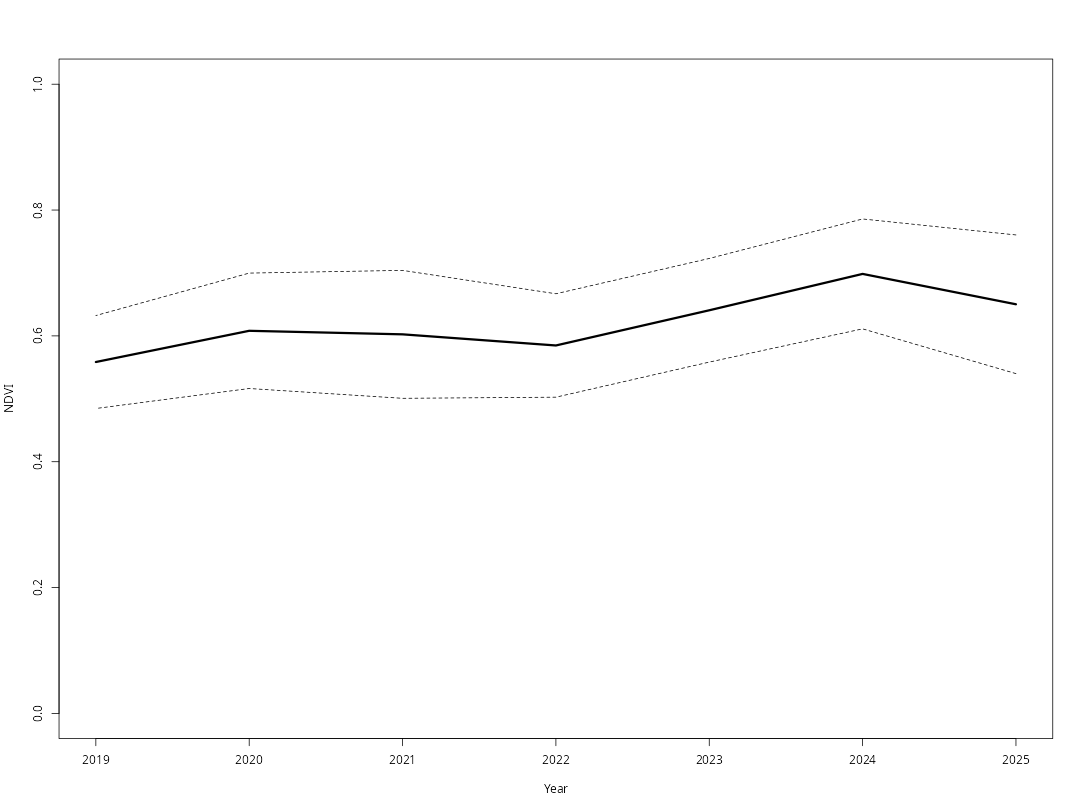

Warning message:
In plot.xy(xy.coords(x, y), type = type, ...) :
  "add" is not a graphical parameter
Warning message:
In plot.xy(xy.coords(x, y), type = type, ...) :
  "add" is not a graphical parameter


In [55]:
plot(x = ndvi_mean_nestboxes$year,
     y = ndvi_mean_nestboxes$ndvi_ymean,
     lwd = 3, type = "l", ylim = c(0, 1),
     xlab = "Year", ylab = "NDVI")
lines(x = ndvi_mean_nestboxes$year,
      y = ndvi_mean_nestboxes$ndvi_ymean - ndvi_mean_nestboxes$ndvi_ystd,
      lwd = 1, lty = 2, add = TRUE)
lines(x = ndvi_mean_nestboxes$year,
      y = ndvi_mean_nestboxes$ndvi_ymean + ndvi_mean_nestboxes$ndvi_ystd,
      lwd = 1, lty = 2, add = TRUE)

## Land cover/use

In [41]:
ndc_datasets()

[1] "ndvi-lter"              "ndvi-snl"               "ndc-geoserver-rasters" 
[4] "lter"                   "snl"                    "groenmonitor-geoserver"

In [42]:
ndc_get(collection = "ndc-geoserver-rasters",
        roi = veluwe,
        trange = tperiod,
        mode = "sf")

Simple feature collection with 7 features and 13 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 3.31 ymin: 50.75 xmax: 7.23 ymax: 53.55
Geodetic CRS:  WGS 84
# A tibble: 7 × 14
  datetime             description         end_datetime `geoserver:layer_name` geoserver:qualified_…¹
  <chr>                <chr>               <chr>        <chr>                  <chr>                 
1 2025-01-01T00:00:00Z Modelled total nit… 2025-01-01T… depo_NTOT_2025         ndc:depo_NTOT_2025    
2 2025-01-01T00:00:00Z Modelled NOx conce… 2025-01-01T… conc_NOx_2025          ndc:conc_NOx_2025     
3 2025-01-01T00:00:00Z Modelled NH3 conce… 2025-01-01T… conc_NH3_2025          ndc:conc_NH3_2025     
4 2024-01-01T00:00:00Z Land use classific… 2024-01-01T… LGN2024_05m            ndc:LGN2024_05m       
5 2024-01-01T00:00:00Z Modelled total nit… 2024-01-01T… depo_NTOT_2024         ndc:depo_NTOT_2024    
6 2024-01-01T00:00:00Z Modelled NOx conce… 2024-01-01T… conc_NOx_2024          ndc:conc

In [43]:
ndc_get(collection = "ndc-geoserver-rasters",
        roi = veluwe,
        trange = tperiod,
        mode = "items") |>
  items_filter("lgn" %in% properties$keywords)

###Items
- matched feature(s): 7
- features (1 item(s) / 6 not fetched):
  - ndc-geoserver-rasters-lgn2024_05m
- assets: download, legend, thumbnail, wcs, wms
- item's fields: 
assets, bbox, collection, geometry, id, links, properties, stac_extensions, stac_version, type